In [1]:
import sklearn 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path_dataset1 = r'C:\Users\abrau\uvic\seng474\seng474_Assignments\assignment3\files\dataset1.csv'
path_dataset2 = r'C:\Users\abrau\uvic\seng474\seng474_Assignments\assignment3\files\dataset2.csv'

dataset1 = pd.read_csv(path_dataset1, header=None).values # 2D dataset
dataset2 = pd.read_csv(path_dataset2, header=None).values # 3D dataset

c:\Users\abrau\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Lloyd's Algorithm 

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a-b)**2))

def uniform_rand_init(data, k):
    indices = np.random.choice(data.shape[0], k, replace=False)
    return data[indices]

def kmeans_plusplus_init(data, k):
    centroids = [data[np.random.randint(data.shape[0])]]
    for i in range(1,k):
        distance = np.array([min([euclidean_distance(point, centroid) for centroid in centroids]) 
                             for point in data])
        probabilities = distance / distance.sum()
        next_centroid = data[np.random.choice(data.shape[0], p=probabilities)]
        centroids.append(next_centroid)
    
    return np.array(centroids)

def kmeans(data, k, init_method='uniform', max_iters = 1000):
    if init_method == 'uniform':
        centroids = uniform_rand_init(data, k)
    elif init_method == 'kmeans++':
        centroids = kmeans_plusplus_init(data, k)
    else:
        raise ValueError('Invalid initialization method. Use uniform or kmeans++')
    
    for i in range(max_iters):
        labels = np.array([np.argmin([euclidean_distance(point, centroid) for centroid in centroids]) 
                           for point in data])
        new_centroids = np.array([data[labels == j].mean(axis = 0) for j in range(k)])
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids

    return centroids, labels

def calculate_sse(data, centroids, labels):
    sse = 0
    for i in range(len(data)):
        sse += euclidean_distance(data[i], centroids[labels[i]]) ** 2
    return sse


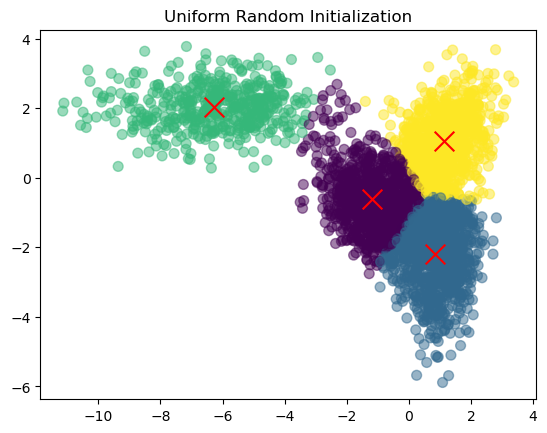

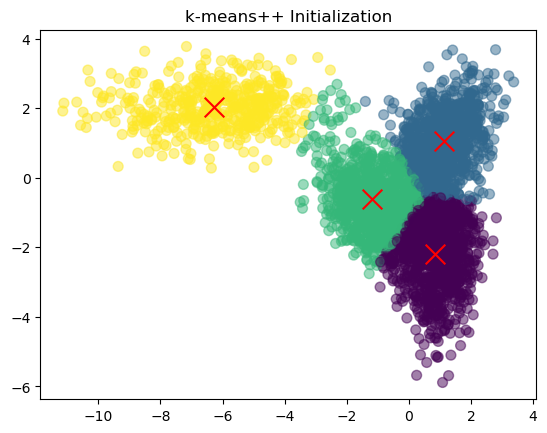

SSE for Uniform Random Initialization: 5117.468273281027
SSE for k-means++ Initialization: 5117.468273281027


In [3]:
k = 4
centroids_uniform_1, labels_uniform_1 = kmeans(dataset1, k, init_method='uniform')
centorids_kmeanspp_1, labels_kmeanspp_1 = kmeans(dataset1, k, init_method='kmeans++')

sse_uniform = calculate_sse(dataset1, centroids_uniform_1, labels_uniform_1)
sse_kmeans = calculate_sse(dataset1, centorids_kmeanspp_1, labels_kmeanspp_1)

def plot_cluster(data, labels, centroids, title):
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', s=50, alpha=0.5)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200)
    plt.title(title)
    plt.show()

plot_cluster(dataset1, labels_uniform_1, centroids_uniform_1, 'Uniform Random Initialization')
plot_cluster(dataset1, labels_kmeanspp_1, centorids_kmeanspp_1, 'k-means++ Initialization')
print(f"SSE for Uniform Random Initialization: {sse_uniform}")
print(f"SSE for k-means++ Initialization: {sse_kmeans}")

In [4]:
import plotly.express as px

# Function to plot 3D clusters interactively
def plot_3d_clusters_interactive(data, labels, centroids, title):
    # Create a DataFrame for Plotly
    df = pd.DataFrame(data, columns=['Feature 1', 'Feature 2', 'Feature 3'])
    df['Cluster'] = labels  # Add cluster labels to the DataFrame
    
    # Create an interactive 3D scatter plot for data points
    fig = px.scatter_3d(df, x='Feature 1', y='Feature 2', z='Feature 3', color='Cluster',
                        title=title, color_continuous_scale='viridis')
    
    # Add centroids to the plot
    centroids_df = pd.DataFrame(centroids, columns=['Feature 1', 'Feature 2', 'Feature 3'])
    centroids_df['Cluster'] = 'Centroids'  # Add a label for centroids
    fig.add_trace(px.scatter_3d(centroids_df, x='Feature 1', y='Feature 2', z='Feature 3', 
                                color='Cluster', color_discrete_sequence=['red']).data[0])
    
    # Update marker size for centroids
    fig.update_traces(marker=dict(size=5), selector=dict(mode='markers'))  # Adjust marker size for data points
    fig.update_traces(marker=dict(size=10, symbol='x'), selector=dict(name='Centroids'))  # Adjust marker size for centroids
    
    # Show the plot
    fig.show()

# Example usage for dataset2 (3D data)
k = 2
centroids_uniform, labels_uniform = kmeans(dataset2, k, init_method='uniform')
centroids_kmeanspp, labels_kmeanspp = kmeans(dataset2, k, init_method='kmeans++')

# Calculate SSE for both initialization methods
sse_uniform_3d = calculate_sse(dataset2, centroids_uniform, labels_uniform)
sse_kmeanspp_3d = calculate_sse(dataset2, centroids_kmeanspp, labels_kmeanspp)

# Print the SSE for both initialization methods
print(f"SSE for Uniform Random Initialization (3D): {sse_uniform_3d}")
print(f"SSE for k-means++ Initialization (3D): {sse_kmeanspp_3d}")

# Plot the results interactively
plot_3d_clusters_interactive(dataset2, labels_uniform, centroids_uniform, 'Uniform Random Initialization (3D)')
plot_3d_clusters_interactive(dataset2, labels_kmeanspp, centroids_kmeanspp, 'k-means++ Initialization (3D)')

SSE for Uniform Random Initialization (3D): 969423.2711475022
SSE for k-means++ Initialization (3D): 969423.2711475022


In [5]:
from sklearn.metrics import silhouette_score

# Range of k values to try
k_values = range(2, 11)
num_runs = 10  # Number of runs per k

# Function to find the best SSE for each k
def find_best_sse(data, k_values, num_runs, init_method):
    best_sses = []
    silhouette_scores = []

    for k in k_values:
        min_sse = float('inf')
        best_labels = None

        for _ in range(num_runs):
            centroids, labels = kmeans(data, k, init_method=init_method)
            sse = calculate_sse(data, centroids, labels)

            if sse < min_sse:
                min_sse = sse
                best_labels = labels

        best_sses.append(min_sse)

        # Compute Silhouette Score (only for k > 1)
        if k > 1:
            silhouette_scores.append(silhouette_score(data, best_labels))
        else:
            silhouette_scores.append(-1)  # Invalid silhouette score for k=1

    return best_sses, silhouette_scores

# Improved elbow detection using Knee Method
def find_elbow_point(k_values, sses):
    k_values = np.array(k_values)
    sses = np.array(sses)

    # Normalize k and SSE values
    k_norm = (k_values - k_values.min()) / (k_values.max() - k_values.min())
    sse_norm = (sses - sses.min()) / (sses.max() - sses.min())

    # Compute distances from a straight line connecting first and last points
    distances = np.abs((sse_norm[0] - sse_norm[-1]) * k_norm - 
                       (k_norm[0] - k_norm[-1]) * sse_norm + 
                       k_norm[0] * sse_norm[-1] - k_norm[-1] * sse_norm[0]) / \
                np.sqrt((sse_norm[0] - sse_norm[-1])**2 + (k_norm[0] - k_norm[-1])**2)

    elbow_index = np.argmax(distances)  # Find the maximum curvature
    return k_values[elbow_index]

# Function to plot SSE vs. k and highlight the elbow point
def plot_sse_with_elbow(k_values, sses_uniform, sses_kmeanspp, elbow_uniform, elbow_kmeanspp, title):
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, sses_uniform, marker='o', label='Uniform Initialization')
    plt.plot(k_values, sses_kmeanspp, marker='o', label='k-means++ Initialization')
    
    # Highlight the elbow points
    plt.axvline(x=elbow_uniform, color='blue', linestyle='--', label=f'Elbow (Uniform): k={elbow_uniform}')
    plt.axvline(x=elbow_kmeanspp, color='orange', linestyle='--', label=f'Elbow (k-means++): k={elbow_kmeanspp}')
    
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Sum of Squared Errors (SSE)')
    plt.title(title)
    plt.legend()
    plt.show()

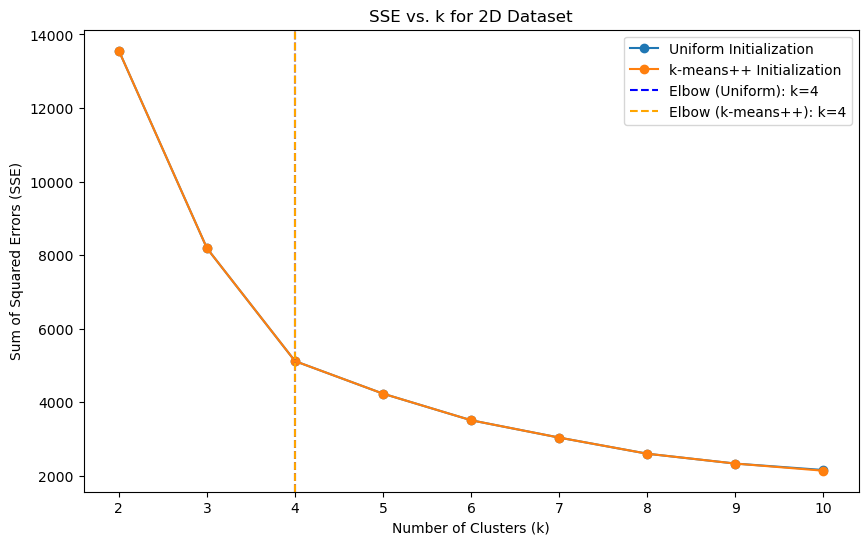

Optimal k for 2D Dataset (dataset1):
Uniform Initialization: k = 4, SSE = 5117.468273281027, Silhouette Score = 0.493
k-means++ Initialization: k = 4, SSE = 5117.468273281027, Silhouette Score = 0.493


In [6]:
# Find best SSEs for dataset1 (2D)
best_sses_uniform_2D, silhouette_scores_uniform_2D = find_best_sse(dataset1, k_values, num_runs, init_method='uniform')
best_sses_kmeanspp_2D, silhouette_scores_kmeanspp_2D = find_best_sse(dataset1, k_values, num_runs, init_method='kmeans++')

# Find the elbow point for dataset1 (2D)
elbow_uniform_2D = find_elbow_point(k_values, best_sses_uniform_2D)
elbow_kmeanspp_2D = find_elbow_point(k_values, best_sses_kmeanspp_2D)

# Plot for dataset1 (2D)
plot_sse_with_elbow(k_values, best_sses_uniform_2D, best_sses_kmeanspp_2D, elbow_uniform_2D, elbow_kmeanspp_2D, 'SSE vs. k for 2D Dataset')

# Output the optimal k and SSE for dataset1 (2D)
print("Optimal k for 2D Dataset (dataset1):")
print(f"Uniform Initialization: k = {elbow_uniform_2D}, SSE = {best_sses_uniform_2D[elbow_uniform_2D - k_values[0]]}, Silhouette Score = {silhouette_scores_uniform_2D[elbow_uniform_2D - k_values[0]]:.3f}")
print(f"k-means++ Initialization: k = {elbow_kmeanspp_2D}, SSE = {best_sses_kmeanspp_2D[elbow_kmeanspp_2D - k_values[0]]}, Silhouette Score = {silhouette_scores_kmeanspp_2D[elbow_kmeanspp_2D - k_values[0]]:.3f}")

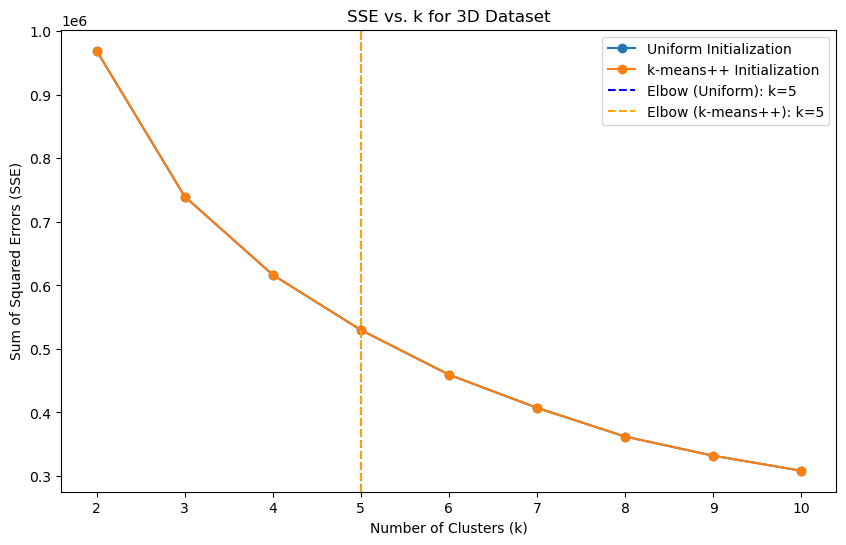

Optimal k for 3D Dataset (dataset2):
Uniform Initialization: k = 5, SSE = 529867.9227800659, Silhouette Score = 0.267
k-means++ Initialization: k = 5, SSE = 529859.1889744402, Silhouette Score = 0.267


In [8]:
# Find best SSEs for dataset2 (3D)
best_sses_uniform_3D, silhouette_scores_uniform_3D = find_best_sse(dataset2, k_values, num_runs, init_method='uniform')
best_sses_kmeanspp_3D, silhouette_scores_kmeanspp_3D = find_best_sse(dataset2, k_values, num_runs, init_method='kmeans++')

# Find the elbow point for dataset2 (3D)
elbow_uniform_3D = find_elbow_point(k_values, best_sses_uniform_3D)
elbow_kmeanspp_3D = find_elbow_point(k_values, best_sses_kmeanspp_3D)

# Plot for dataset2 (3D)
plot_sse_with_elbow(k_values, best_sses_uniform_3D, best_sses_kmeanspp_3D, elbow_uniform_3D, elbow_kmeanspp_3D, 'SSE vs. k for 3D Dataset')

# Output the optimal k for dataset2 (3D)
print("Optimal k for 3D Dataset (dataset2):")
print(f"Uniform Initialization: k = {elbow_uniform_3D}, SSE = {best_sses_uniform_3D[elbow_uniform_3D - k_values[0]]}, Silhouette Score = {silhouette_scores_uniform_3D[elbow_uniform_3D - k_values[0]]:.3f}")
print(f"k-means++ Initialization: k = {elbow_kmeanspp_3D}, SSE = {best_sses_kmeanspp_3D[elbow_kmeanspp_3D - k_values[0]]}, Silhouette Score = {silhouette_scores_kmeanspp_3D[elbow_kmeanspp_3D - k_values[0]]:.3f}")

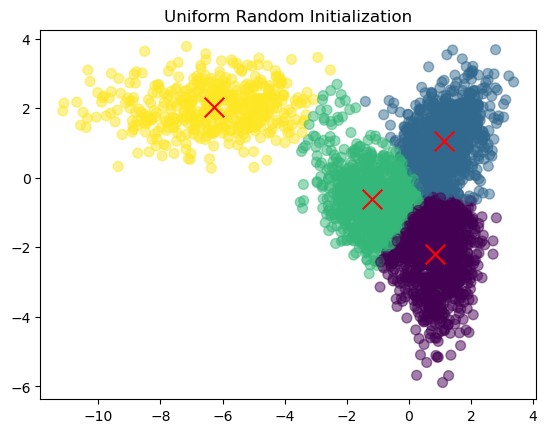

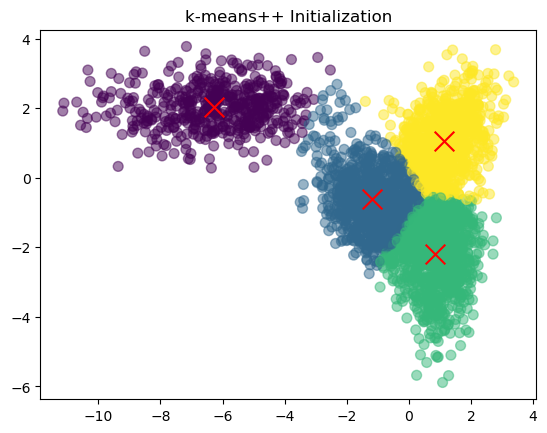

In [9]:
k_uniform, k_kplusplus = elbow_uniform_2D, elbow_kmeanspp_2D
centroids_uniform_1, labels_uniform_1 = kmeans(dataset1, k_uniform, init_method='uniform')
centorids_kmeanspp_1, labels_kmeanspp_1 = kmeans(dataset1, k_kplusplus, init_method='kmeans++')

def plot_cluster(data, labels, centroids, title):
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', s=50, alpha=0.5)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200)
    plt.title(title)
    plt.show()

plot_cluster(dataset1, labels_uniform_1, centroids_uniform_1, 'Uniform Random Initialization')
plot_cluster(dataset1, labels_kmeanspp_1, centorids_kmeanspp_1, 'k-means++ Initialization')

In [10]:
import plotly.express as px

# Function to plot 3D clusters interactively
def plot_3d_clusters_interactive(data, labels, centroids, title):
    # Create a DataFrame for Plotly
    df = pd.DataFrame(data, columns=['Feature 1', 'Feature 2', 'Feature 3'])
    df['Cluster'] = labels  # Add cluster labels to the DataFrame
    
    # Create an interactive 3D scatter plot for data points
    fig = px.scatter_3d(df, x='Feature 1', y='Feature 2', z='Feature 3', color='Cluster',
                        title=title, color_continuous_scale='viridis')
    
    # Add centroids to the plot
    centroids_df = pd.DataFrame(centroids, columns=['Feature 1', 'Feature 2', 'Feature 3'])
    centroids_df['Cluster'] = 'Centroids'  # Add a label for centroids
    fig.add_trace(px.scatter_3d(centroids_df, x='Feature 1', y='Feature 2', z='Feature 3', 
                                color='Cluster', color_discrete_sequence=['red']).data[0])
    
    # Update marker size for centroids
    fig.update_traces(marker=dict(size=5), selector=dict(mode='markers'))  # Adjust marker size for data points
    fig.update_traces(marker=dict(size=10, symbol='x'), selector=dict(name='Centroids'))  # Adjust marker size for centroids
    
    # Show the plot
    fig.show()

# Example usage for dataset2 (3D data)
k_uniform, k_kplusplus = elbow_uniform_3D, elbow_kmeanspp_3D
centroids_uniform, labels_uniform = kmeans(dataset2, k_uniform, init_method='uniform')
centroids_kmeanspp, labels_kmeanspp = kmeans(dataset2, k_kplusplus, init_method='kmeans++')

# Plot the results interactively
plot_3d_clusters_interactive(dataset2, labels_uniform, centroids_uniform, 'Uniform Random Initialization (3D)')
plot_3d_clusters_interactive(dataset2, labels_kmeanspp, centroids_kmeanspp, 'k-means++ Initialization (3D)')